<a href="https://colab.research.google.com/github/anakhatech/Smart-Water-Management-System-AI/blob/main/Smart_Water_Management_using_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SMART WATER MANAGEMENT USING AI
# Machine Learning Project

#PHASE 1: DATA COLLECTION & UNDERSTANDING

In [ ]:
print("Smart Water Management System using AI")

Smart Water Management System using AI


##Step 1: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##STEP 2: Upload the Datase

In [ ]:
# STEP 2: Upload the Dataset

from google.colab import files

uploaded = files.upload()

Saving location_aware_gis_leakage_dataset.csv to location_aware_gis_leakage_dataset.csv


##STEP 3: Load and View the Dataset

In [ ]:
df = pd.read_csv("location_aware_gis_leakage_dataset.csv")

# Display the first 5 rows
df.head()

,Pressure,Flow_Rate,Temperature,Vibration,RPM,Operational_Hours,Zone,Block,Pipe,Location_Code,Latitude,Longitude,Leakage_Flag
0,64.967142,73.643605,96.607526,2.928288,2104.485874,3380,Zone_4,Block_2,Pipe_3,Zone_4_Block_2_Pipe_3,25.162560,55.238018,0
1,58.617357,73.198788,98.472503,2.983672,2084.997078,2235,Zone_3,Block_4,Pipe_1,Zone_3_Block_4_Pipe_1,25.090473,55.162476,0
2,66.476885,53.065352,97.013095,3.032147,1719.044046,8762,Zone_2,Block_2,Pipe_5,Zone_2_Block_2_Pipe_5,25.279196,55.287601,0
3,75.230299,75.048647,100.552090,3.473431,2173.875267,8931,Zone_5,Block_3,Pipe_2,Zone_5_Block_3_Pipe_2,25.198326,55.269765,0
4,57.658466,90.992436,105.985893,2.626391,1552.975197,3403,Zone_3,Block_1,Pipe_1,Zone_3_Block_1_Pipe_1,25.099630,55.166098,0


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/16LdpwBArSqiRbRV2nApqYdd44JQ70A7MvegKWlkq8Vw/edit#gid=0


## STEP 4: Understand the Dataset

In [ ]:
# Check the number of rows and columns
print("Dataset Shape:", df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns)

# Display basic information about the dataset
print("\nDataset Information:")
df.info()

Dataset Shape: (5000, 13)

Column Names:
Index(['Pressure', 'Flow_Rate', 'Temperature', 'Vibration', 'RPM',
       'Operational_Hours', 'Zone', 'Block', 'Pipe', 'Location_Code',
       'Latitude', 'Longitude', 'Leakage_Flag'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Pressure           5000 non-null   float64
 1   Flow_Rate          5000 non-null   float64
 2   Temperature        5000 non-null   float64
 3   Vibration          5000 non-null   float64
 4   RPM                5000 non-null   float64
 5   Operational_Hours  5000 non-null   int64  
 6   Zone               5000 non-null   object 
 7   Block              5000 non-null   object 
 8   Pipe               5000 non-null   object 
 9   Location_Code      5000 non-null   object 
 10  Latitude           5000 non-null   float6

## STEP 5: Check Missing Values and Duplicate Rows

In [ ]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())

Missing Values:
Pressure             0
Flow_Rate            0
Temperature          0
Vibration            0
RPM                  0
Operational_Hours    0
Zone                 0
Block                0
Pipe                 0
Location_Code        0
Latitude             0
Longitude            0
Leakage_Flag         0
dtype: int64

Number of Duplicate Rows:
0


## STEP 6: Explore Leakage Distribution

Leakage_Flag
0    4677
1     323
Name: count, dtype: int64


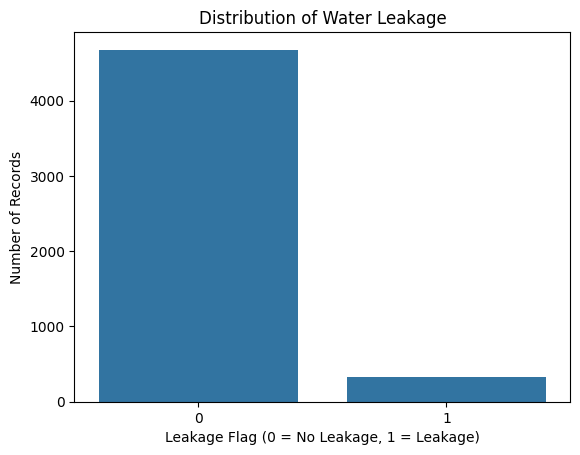

In [ ]:
# Count leakage and non-leakage records
print(df["Leakage_Flag"].value_counts())

# Visualize the distribution
sns.countplot(data=df, x="Leakage_Flag")

plt.title("Distribution of Water Leakage")
plt.xlabel("Leakage Flag (0 = No Leakage, 1 = Leakage)")
plt.ylabel("Number of Records")

plt.show()

#PHASE 2: DATA PREPROCESSING

## STEP 7: Separate Features and Target

In [ ]:
# Input features
X = df.drop("Leakage_Flag", axis=1)

# Target variable
y = df["Leakage_Flag"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (5000, 12)
Target shape: (5000,)


## STEP 8: Convert Categorical Data into Numerical Data

In [ ]:
# Convert text columns into numerical columns
X = pd.get_dummies(X, drop_first=True)

print("New Features Shape:", X.shape)

# Display the first 5 rows
X.head()

New Features Shape: (5000, 144)


,Pressure,Flow_Rate,Temperature,Vibration,RPM,Operational_Hours,Latitude,Longitude,Zone_Zone_2,Zone_Zone_3,...,Location_Code_Zone_5_Block_4_Pipe_1,Location_Code_Zone_5_Block_4_Pipe_2,Location_Code_Zone_5_Block_4_Pipe_3,Location_Code_Zone_5_Block_4_Pipe_4,Location_Code_Zone_5_Block_4_Pipe_5,Location_Code_Zone_5_Block_5_Pipe_1,Location_Code_Zone_5_Block_5_Pipe_2,Location_Code_Zone_5_Block_5_Pipe_3,Location_Code_Zone_5_Block_5_Pipe_4,Location_Code_Zone_5_Block_5_Pipe_5
0,64.967142,73.643605,96.607526,2.928288,2104.485874,3380,25.162560,55.238018,False,False,...,False,False,False,False,False,False,False,False,False,False
1,58.617357,73.198788,98.472503,2.983672,2084.997078,2235,25.090473,55.162476,False,True,...,False,False,False,False,False,False,False,False,False,False
2,66.476885,53.065352,97.013095,3.032147,1719.044046,8762,25.279196,55.287601,True,False,...,False,False,False,False,False,False,False,False,False,False
3,75.230299,75.048647,100.552090,3.473431,2173.875267,8931,25.198326,55.269765,False,False,...,False,False,False,False,False,False,False,False,False,False
4,57.658466,90.992436,105.985893,2.626391,1552.975197,3403,25.099630,55.166098,False,True,...,False,False,False,False,False,False,False,False,False,False


### STEP 9: Split the Data into Training and Testing Sets

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (4000, 144)
Testing Data Shape: (1000, 144)


#🤖 PHASE 3: AI / MACHINE LEARNING

## STEP 10: Handle Imbalanced Data using SMOTE


In [ ]:
!pip install imbalanced-learn


from imblearn.over_sampling import SMOTE

# Create SMOTE object
smote = SMOTE(random_state=42)

# Balance the training data
X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train,
    y_train
)

# Display the class distribution
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_balanced.value_counts())

Before SMOTE:
Leakage_Flag
0    3742
1     258
Name: count, dtype: int64

After SMOTE:
Leakage_Flag
0    3742
1    3742
Name: count, dtype: int64


##STEP 11: Train the AI Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create the AI model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

# Train the model
model.fit(X_train_balanced, y_train_balanced)

print("AI Model trained successfully!")

AI Model trained successfully!


## 🤖 STEP 12: Make Predictions

In [ ]:
# Predict leakage using the trained AI model
y_pred = model.predict(X_test)

# Display the first 10 predictions
print("First 10 AI Predictions:")
print(y_pred[:10])

First 10 AI Predictions:
[0 0 0 0 1 0 0 0 0 0]


#STEP 13: Evaluate the AI Model

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Model Accuracy: 99.6 %

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       935
           1       1.00      0.94      0.97        65

    accuracy                           1.00      1000
   macro avg       1.00      0.97      0.98      1000
weighted avg       1.00      1.00      1.00      1000


Confusion Matrix:
[[935   0]
 [  4  61]]


#PHASE 4: MODEL ANALYSIS

## STEP 14: Feature Importance Analysis

In [ ]:
# Create a DataFrame showing feature importance
feature_importance = pd.DataFrame({
    "Feature": X_train_balanced.columns,
    "Importance": model.feature_importances_
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display the top 10 most important features
feature_importance.head(10)

,Feature,Importance
1,Flow_Rate,0.363286
0,Pressure,0.315590
7,Longitude,0.039556
6,Latitude,0.037598
5,Operational_Hours,0.020602
4,RPM,0.017973
15,Block_Block_5,0.015603
3,Vibration,0.014984
10,Zone_Zone_4,0.014045
2,Temperature,0.013905


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=feature_importance)

https://docs.google.com/spreadsheets/d/1fTdBK9PkXr_aQG6P9cEBKjBwNe97LLyxgiaeWmuziX0/edit#gid=0


## 📊 STEP 15: Visualize Top 10 Important Features

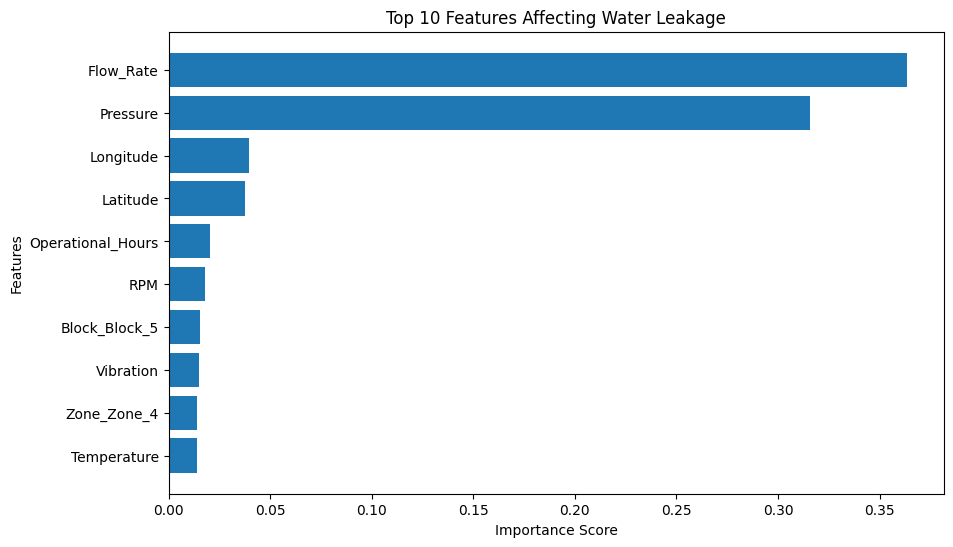

In [ ]:
# Select the top 10 features
top_10 = feature_importance.head(10)

# Create the graph
plt.figure(figsize=(10, 6))

plt.barh(top_10["Feature"], top_10["Importance"])

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Features Affecting Water Leakage")

# Show the most important feature at the top
plt.gca().invert_yaxis()

plt.show()

#🚰 PHASE 5: SMART WATER MANAGEMENT DEMO

##STEP 16: Test the AI Model with a New Water Reading

In [ ]:
# STEP 16: Test the AI Model with a New Water Reading

# Select one test record
new_data = X_test.iloc[[0]]

# Predict using the trained AI model
prediction = model.predict(new_data)

# Show the result
if prediction[0] == 1:
    print("🚨 ALERT: Water Leakage Detected!")
else:
    print("✅ No Water Leakage Detected.")

✅ No Water Leakage Detected.


## 🚀 STEP 17: Create Water Leakage Prediction Function

In [ ]:
def predict_leakage(data):

    prediction = model.predict(data)
    probability = model.predict_proba(data)

    if prediction[0] == 1:
        print("🚨 ALERT: Water Leakage Detected!")
        print("Leakage Probability:", round(probability[0][1] * 100, 2), "%")
    else:
        print("✅ No Water Leakage Detected.")
        print("Leakage Probability:", round(probability[0][1] * 100, 2), "%")

In [ ]:
# Test the AI prediction function

predict_leakage(X_test.iloc[[4]])

🚨 ALERT: Water Leakage Detected!
Leakage Probability: 77.0 %


#📱 PHASE 6: CONVERT AI MODEL INTO A WEB APP

## STEP 18: Save the Trained AI Model

In [ ]:
import joblib

# Save the trained AI model
joblib.dump(model, "water_leakage_model.pkl")

# Save the feature column names
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

print("AI model and feature columns saved successfully!")

AI model and feature columns saved successfully!


### 📱 STEP 19: Download the AI Model Files

In [60]:
from google.colab import files

# Download trained AI model
files.download("water_leakage_model.pkl")

# Download feature columns
files.download("feature_columns.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>